In [1]:
import numpy as np

def entropy(pos, neg):
    total = pos + neg
    if total == 0:
        return 0
    p_pos = pos / total
    p_neg = neg / total
    e = 0
    if p_pos > 0:
        e -= p_pos * np.log2(p_pos)
    if p_neg > 0:
        e -= p_neg * np.log2(p_neg)
    return e

def information_gain(total_pos, total_neg, subsets):
    """subsets: list of (pos, neg) tuples for each attribute value"""
    total = total_pos + total_neg
    parent_entropy = entropy(total_pos, total_neg)
    weighted_entropy = sum(
        ((p + n) / total) * entropy(p, n) for p, n in subsets
    )
    return parent_entropy - weighted_entropy

# Total: 5 positive (+), 5 negative (-)
total_pos, total_neg = 5, 5
parent_e = entropy(total_pos, total_neg)
print(f"Entropy of entire dataset S: {parent_e:.4f}")

# a2: T -> (4+, 0-), F -> (1+, 5-)
ig_a2 = information_gain(total_pos, total_neg, [(4, 0), (1, 5)])
print(f"\nInformation Gain for a2: {ig_a2:.4f}")

# a3: T -> (3+, 2-), F -> (2+, 3-)
ig_a3 = information_gain(total_pos, total_neg, [(3, 2), (2, 3)])
print(f"Information Gain for a3: {ig_a3:.4f}")

winner = 'a2' if ig_a2 > ig_a3 else 'a3'
print(f"\nConclusion: '{winner}' has higher Information Gain => chosen as splitting node.")

Entropy of entire dataset S: 1.0000

Information Gain for a2: 0.6100
Information Gain for a3: 0.0290

Conclusion: 'a2' has higher Information Gain => chosen as splitting node.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [3]:
# Load IRIS dataset
iris_df = pd.read_csv('iris.csv')
print("Shape:", iris_df.shape)
iris_df.head()

Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
X_iris = iris_df.iloc[:, :-1]   # features
y_iris = iris_df.iloc[:, -1]    # target (species)

# 80-20 train-test split
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train_i)} samples | Test: {len(X_test_i)} samples")

Train: 120 samples | Test: 30 samples


In [5]:
# Build Decision Tree Classifier
dt_iris = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_iris.fit(X_train_i, y_train_i)

y_pred_i = dt_iris.predict(X_test_i)
acc_iris = accuracy_score(y_test_i, y_pred_i)
print(f"Accuracy Score (IRIS): {acc_iris * 100:.2f}%")

Accuracy Score (IRIS): 100.00%


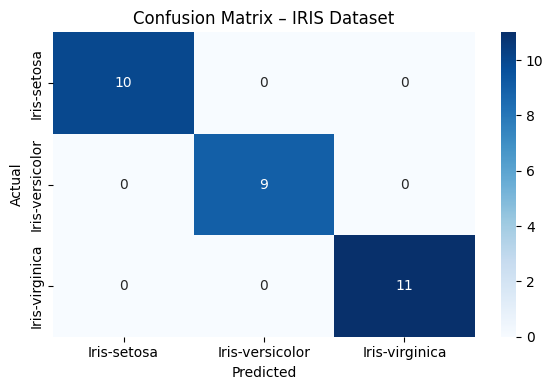


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [6]:
# Confusion Matrix
labels_iris = dt_iris.classes_
cm_iris = confusion_matrix(y_test_i, y_pred_i, labels=labels_iris)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_iris, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_iris, yticklabels=labels_iris)
plt.title('Confusion Matrix – IRIS Dataset')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_i, y_pred_i))

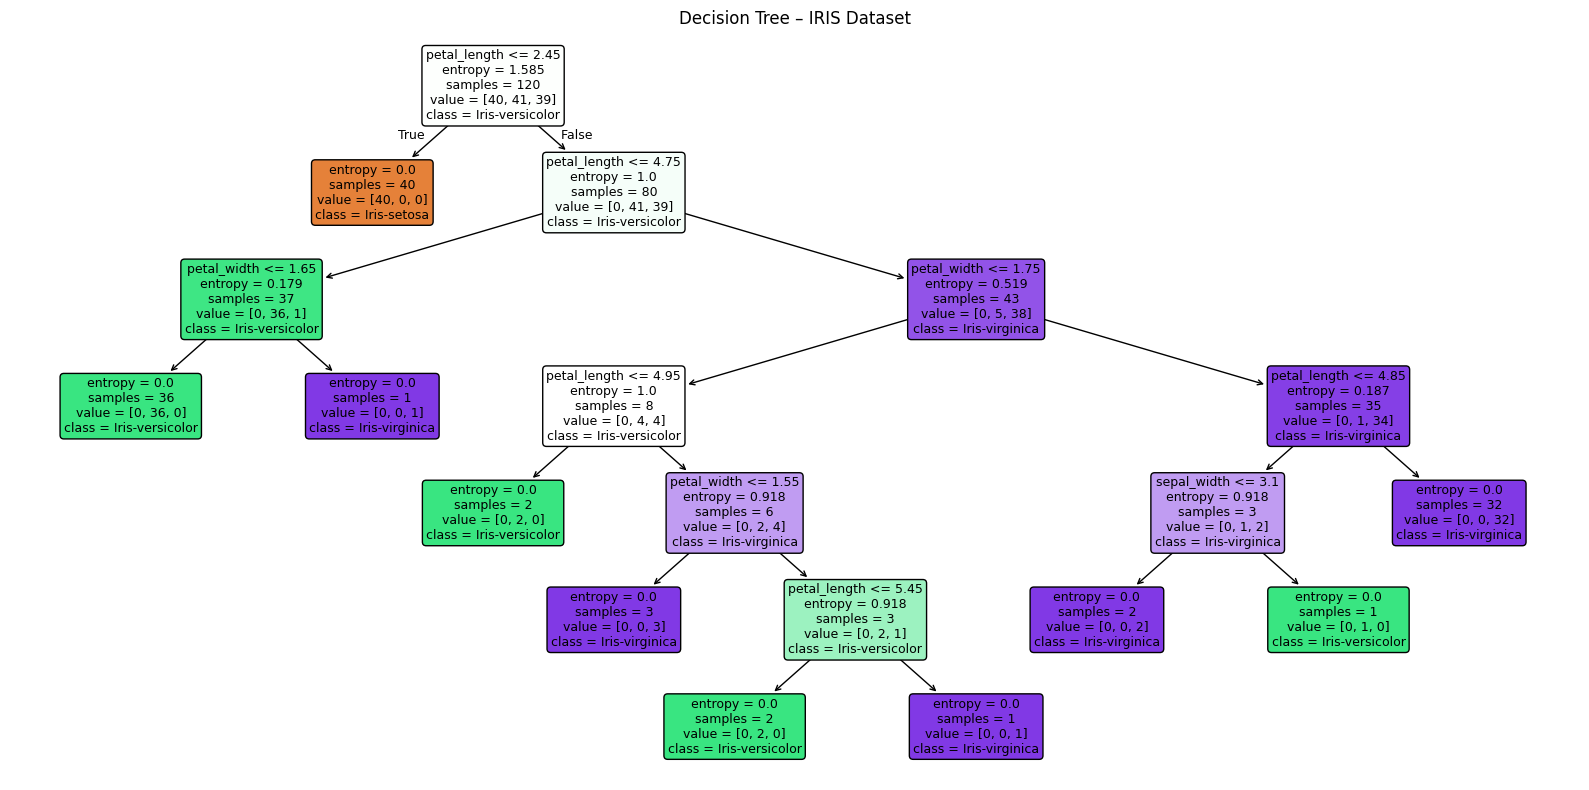

In [7]:
# Visualize Decision Tree
plt.figure(figsize=(16, 8))
plot_tree(dt_iris,
          feature_names=X_iris.columns.tolist(),
          class_names=labels_iris,
          filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree – IRIS Dataset')
plt.tight_layout()
plt.show()

In [8]:
# Load Drug dataset
drug_df = pd.read_csv('drug.csv')
print("Shape:", drug_df.shape)
drug_df.head()

Shape: (200, 6)


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [9]:
# Encode categorical columns
drug_encoded = drug_df.copy()
le = LabelEncoder()
for col in drug_encoded.select_dtypes(include='object').columns:
    drug_encoded[col] = le.fit_transform(drug_encoded[col])

X_drug = drug_encoded.iloc[:, :-1]
y_drug = drug_encoded.iloc[:, -1]

# 80-20 split
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_drug, y_drug, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train_d)} samples | Test: {len(X_test_d)} samples")

Train: 160 samples | Test: 40 samples


In [10]:
# Build Decision Tree Classifier
dt_drug = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_drug.fit(X_train_d, y_train_d)

y_pred_d = dt_drug.predict(X_test_d)
acc_drug = accuracy_score(y_test_d, y_pred_d)
print(f"Accuracy Score (Drug): {acc_drug * 100:.2f}%")

Accuracy Score (Drug): 100.00%


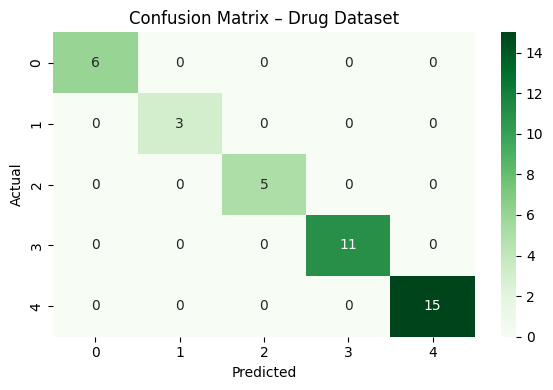


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00        11
           4       1.00      1.00      1.00        15

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [11]:
# Confusion Matrix
cm_drug = confusion_matrix(y_test_d, y_pred_d)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_drug, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix – Drug Dataset')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_d, y_pred_d))

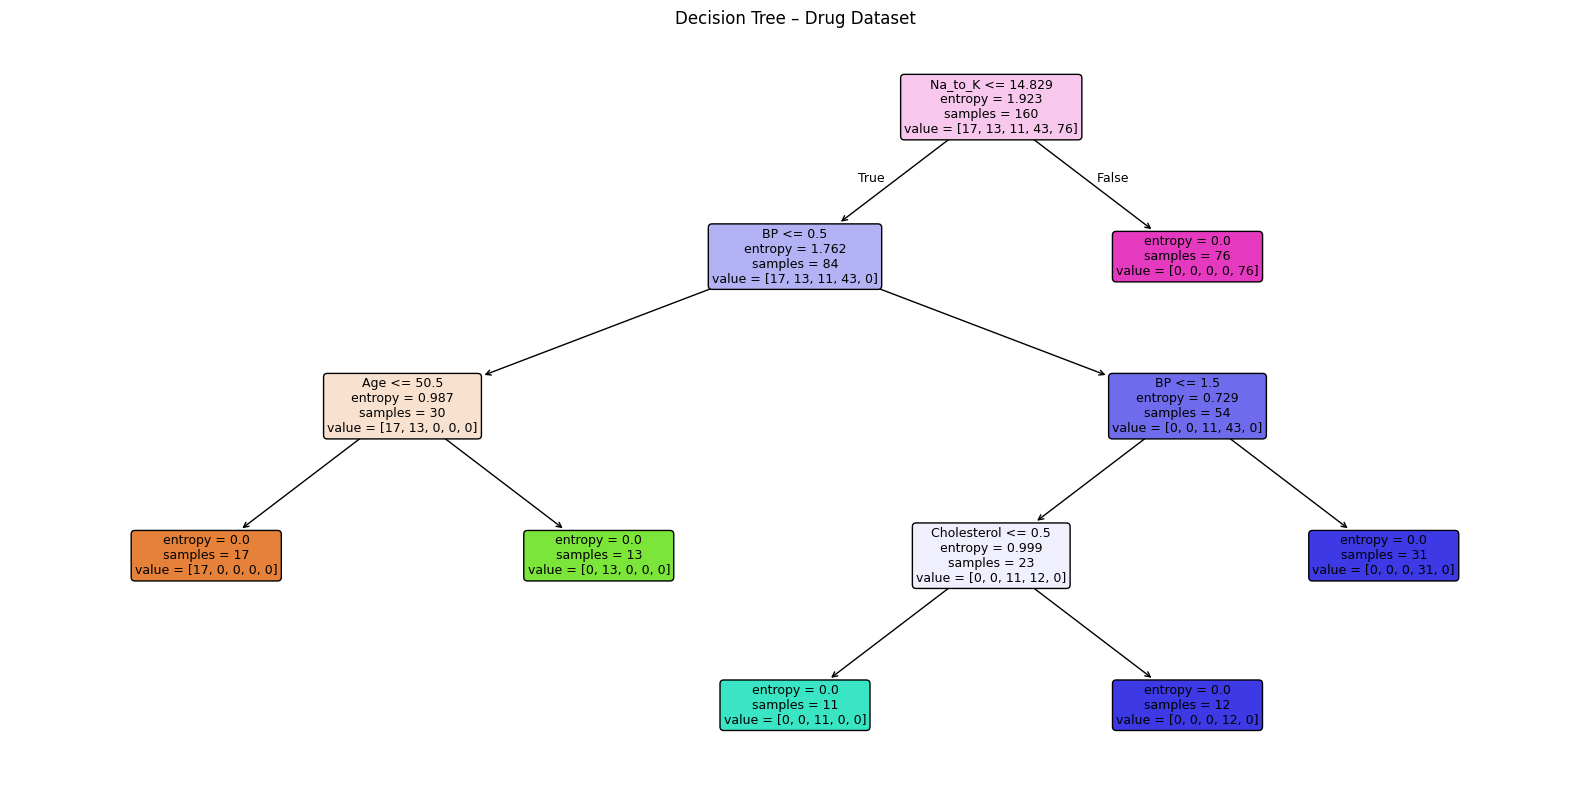

In [12]:
# Visualize Decision Tree
plt.figure(figsize=(16, 8))
plot_tree(dt_drug,
          feature_names=X_drug.columns.tolist(),
          filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree – Drug Dataset')
plt.tight_layout()
plt.show()

In [13]:
# Load Petrol Consumption dataset
petrol_df = pd.read_csv('petrol_consumption.csv')
print("Shape:", petrol_df.shape)
petrol_df.head()

Shape: (48, 5)


,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
0,9.0,3571,1976,0.525,541
1,9.0,4092,1250,0.572,524
2,9.0,3865,1586,0.580,561
3,7.5,4870,2351,0.529,414
4,8.0,4399,431,0.544,410


In [14]:
X_petrol = petrol_df.iloc[:, :-1]   # features
y_petrol = petrol_df.iloc[:, -1]    # target (consumption)

# 80-20 split
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_petrol, y_petrol, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train_p)} samples | Test: {len(X_test_p)} samples")

Train: 38 samples | Test: 10 samples


In [15]:
# Build Decision Tree Regressor
dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train_p, y_train_p)

y_pred_p = dt_reg.predict(X_test_p)

In [16]:
# Regression Metrics
mae  = mean_absolute_error(y_test_p, y_pred_p)
mse  = mean_squared_error(y_test_p, y_pred_p)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error  (MAE) : {mae:.4f}")
print(f"Mean Squared Error   (MSE) : {mse:.4f}")
print(f"Root Mean Sq. Error (RMSE) : {rmse:.4f}")

Mean Absolute Error  (MAE) : 94.3000
Mean Squared Error   (MSE) : 17347.7000
Root Mean Sq. Error (RMSE) : 131.7107


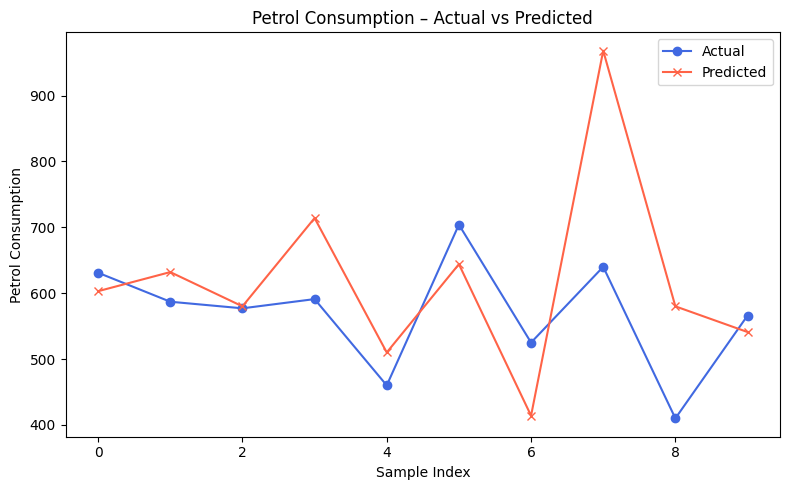

In [17]:
# Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.plot(y_test_p.values, label='Actual', marker='o', color='royalblue')
plt.plot(y_pred_p,        label='Predicted', marker='x', color='tomato')
plt.title('Petrol Consumption – Actual vs Predicted')
plt.xlabel('Sample Index')
plt.ylabel('Petrol Consumption')
plt.legend()
plt.tight_layout()
plt.show()

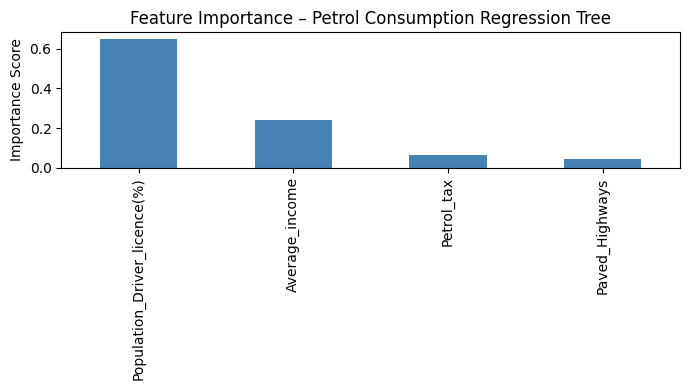

In [18]:
# Feature Importance
importances = pd.Series(dt_reg.feature_importances_, index=X_petrol.columns)
importances.sort_values(ascending=False).plot(
    kind='bar', color='steelblue', figsize=(7, 4)
)
plt.title('Feature Importance – Petrol Consumption Regression Tree')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

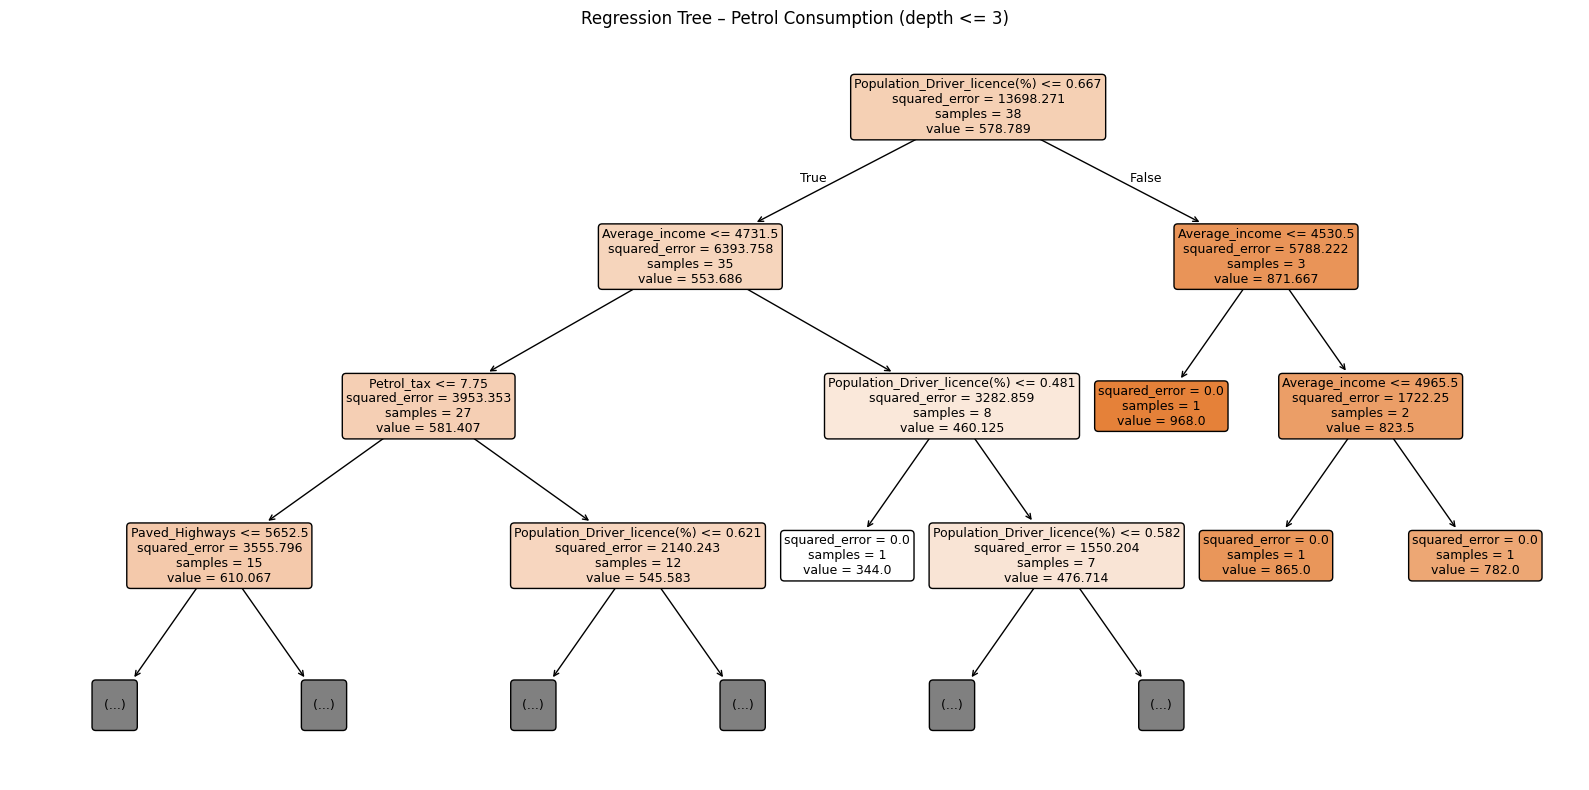

In [19]:
# Visualize Regression Tree (limited depth for readability)
plt.figure(figsize=(16, 8))
plot_tree(dt_reg,
          feature_names=X_petrol.columns.tolist(),
          filled=True, rounded=True, max_depth=3, fontsize=9)
plt.title('Regression Tree – Petrol Consumption (depth <= 3)')
plt.tight_layout()
plt.show()